Data directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data


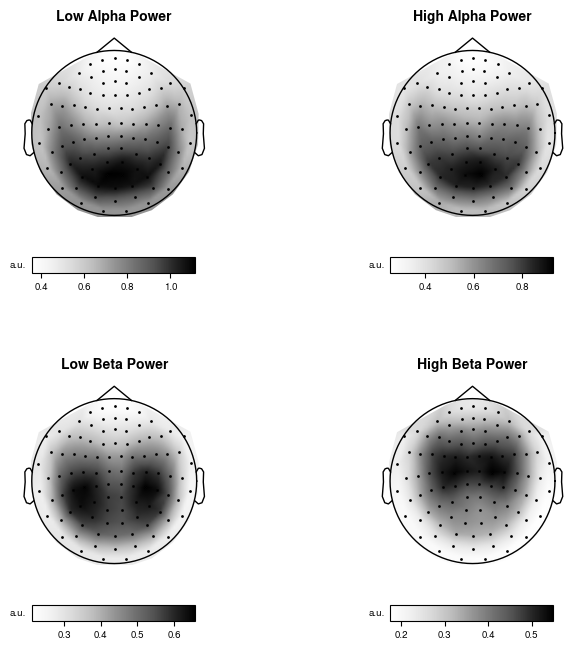

In [1]:
"""
This script plots Supplementary Figure 7, with the topographies of Alpha and Beta Low/High sub-bands power.
"""

import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
import os

datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

pipver = ''
task = 'rest'
phases = ['p2', 'p5']

megtype = 'grad' # 'grad' or 'mag'

# ---- FUNCTIONS ----

# --- Function to plot topography ---
def plot_topo(var, pos, vardict, ax):
    # First topo plot
    im, cm = mne.viz.plot_topomap(var, pos, mask=np.ones((len(var),), dtype=bool), mask_params={'markersize':2, 'marker':'.'}, 
    cmap=vardict['cmap'], vlim=vardict['vlim'], image_interp='linear',
    contours=0, ch_type='mag', axes=ax, sensors='k.', show=False)
    ax.set_title(vardict['title'], fontdict={'fontsize':10}, fontweight='bold')    
    return im


def plot_colorbar_horizontal(im, topo_ax, varunits, title=''):
    clb = plt.colorbar(mappable=im, ax=topo_ax, orientation='horizontal', location='bottom',  aspect=10, shrink=0.5)
    clb.ax.tick_params(labelsize=7)
    clb.ax.set_ylabel(varunits, fontsize=7, rotation='horizontal', verticalalignment='center', labelpad=10)
    cbox = clb.ax.get_position()
    clb.ax.set_position([cbox.x0-0.034, cbox.y0,
                 cbox.width,
                 cbox.height])


# --- End of functions ----
# ------------------------------------------------------------------------------

####################################################################################################

# setting font size to 10
plt.rcParams.update({'font.size': 10})
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]

fig, axs = plt.subplots(2, 2, figsize=(7.2, 7), width_ratios=[1, 1], gridspec_kw={'wspace': 0.1, 'hspace': 0.3, 'left':0.05, 'right':1, 'top':0.92, 'bottom':0.04})

parameters = ['low_alpha_band_power', 'high_alpha_band_power', 'low_beta_band_power', 'high_beta_band_power']

# Loop over parameters and create bar plots and topographies
for i, parameter in enumerate(parameters):
    ax_topo = axs[i//2, i%2]

    topo_file = os.path.join(datadir, f'supp_figure07_{parameter}_{megtype}_topo.tsv')
    df_topo = pd.read_csv(topo_file, sep='\t')

    topovals = df_topo['Mean_Value'].to_numpy(float)
    pos = np.array(df_topo['Positions'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')).tolist())
    im = plot_topo(
        var=topovals,
        pos=pos,
        vardict={
            'cmap': 'Greys',
            'vlim': (topovals.min(), topovals.max()),
            'title': parameter.replace('_', ' ').replace('band ', '').title()
        },
        ax=ax_topo
    )

    plot_colorbar_horizontal(im, ax_topo, varunits='a.u.')

    topobox = ax_topo.get_position()
    ax_topo.set_position([topobox.x0-0.033, topobox.y0,
                topobox.width,
                topobox.height])
    

plt.savefig(os.path.join(f'Supp_Figure07.png'), dpi=300, format='png', transparent=False)
#plt.show()